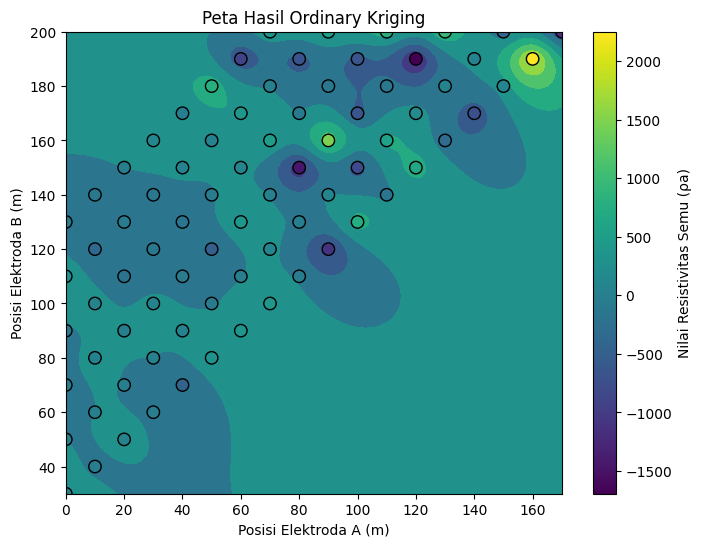

In [ ]:
# ===========================================
# Program Perhitungan & Plot Resistivitas Semu (ρa)
# Menggunakan metode Ordinary Kriging (Interpolasi 2D)
# ===========================================

# Import library yang dibutuhkan
import numpy as np                      # Untuk operasi matematis & array
import matplotlib.pyplot as plt          # Untuk plotting hasil
import pandas as pd                      # Untuk membaca file Excel dan manipulasi data
from pykrige.ok import OrdinaryKriging   # Untuk interpolasi spasial dengan metode Kriging

# Membaca file Excel berisi data hasil akuisisi ERT
keren = r"C:\Users\VELY DF\OneDrive\Documents\RHO APPARENT_KELOMPOK8\data.xlsx"
data = pd.read_excel(keren)              # Membaca data Excel ke dalam DataFrame pandas

# Mengambil setiap kolom dari data Excel
a = np.array(data["A"])                  # Posisi elektroda A
b = np.array(data["B"])                  # Posisi elektroda B
m = np.array(data["M"])                  # Posisi elektroda M
n = np.array(data["N"])                  # Posisi elektroda N
v = np.array(data["V"])                  # Tegangan (volt)
i = np.array(data["I"])                  # Arus (ampere)
j = 10                                   # Jarak antar elektroda (meter) - nilai tetap
dv = np.diff(v, prepend=0)               # Menghitung beda potensial antar data (ΔV)
method = 'S'                             # Menentukan metode konfigurasi elektroda (S/W/G)
 u
# -------------------------------------------
# Membuat class untuk berbagai jenis konfigurasi elektroda
# -------------------------------------------
class Konfigurasi :
    def __init__(self,j, a, b, m, n, v, i, dv):
        # Menyimpan variabel ke dalam objek
        self.a = a
        self.b = b
        self.m = m
        self.n = n
        self.v = v
        self.i = i
        self.dv = dv
        self.j = j
    
    # Metode konfigurasi Schlumberger
    def S(a,b,m,n):
        # Rumus faktor geometri (K) untuk konfigurasi Schlumberger
        return np.pi * (((a*b)**2 + (m*n)**2) / (2 * m * n))

    # Metode konfigurasi Wenner
    def W(j):
        # Rumus faktor geometri (K) untuk konfigurasi Wenner
        return 2 * np.pi * j

    # Metode konfigurasi General (umum)
    def G(A,M,B,N):
        # Rumus faktor geometri umum
        return np.pi * ((1/(A*M)) + (1/(B*N)) - (1/(B*M)) - (1/(A*N)))

# -------------------------------------------
# Fungsi perhitungan resistansi & resistivitas semu
# -------------------------------------------
def R(dv,i):
    # Menghitung resistansi (R = ΔV / I)
    return dv / i

def rho_a(K,R):
    # Menghitung resistivitas semu (ρa = K * R)
    return K * R

# -------------------------------------------
# Menentukan faktor geometri (K) berdasarkan metode
# -------------------------------------------
if method == 'S':
    # Jika menggunakan konfigurasi Schlumberger
    data["K"] = [Konfigurasi.S(a[i], b[i], m[i], n[i]) for i in range(len(a))]
elif method == 'W':
    # Jika menggunakan konfigurasi Wenner
    data["K"] = [Konfigurasi.W(j) for i in range(len(a))]
elif method == 'G':
    # Jika menggunakan konfigurasi General
    data["K"] = [Konfigurasi.G(a[i], m[i], b[i], n[i]) for i in range(len(a))]

# -------------------------------------------
# Menghitung Resistansi (R) dan Resistivitas Semu (ρa)
# -------------------------------------------
data["R"] = R(dv, i)                     # Hitung resistansi
data["rho_a"] = rho_a(data["K"], data["R"])  # Hitung resistivitas semu

# -------------------------------------------
# Menyiapkan data untuk interpolasi Kriging
# -------------------------------------------
x = np.array(data["A"])                  # Koordinat X (posisi elektroda A)
y = np.array(data["B"])                  # Koordinat Y (posisi elektroda B)
z = np.array(data["rho_a"])              # Nilai resistivitas semu

# -------------------------------------------
# Ordinary Kriging: interpolasi nilai resistivitas
# -------------------------------------------
OK = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',         # Model variogram (bisa 'linear', 'gaussian', dll)
    verbose=False,                       # Tidak menampilkan output variogram
    enable_plotting=False                # Tidak menampilkan plot variogram
)

# Membuat grid untuk area interpolasi
gridx = np.linspace(min(x), max(x), 100) # Grid horizontal (100 titik)
gridy = np.linspace(min(y), max(y), 100) # Grid vertikal (100 titik)

# Melakukan prediksi nilai z (ρa) di setiap titik grid
z_pred, ss = OK.execute('grid', gridx, gridy)

# -------------------------------------------
# Visualisasi hasil interpolasi (penampang resistivitas)9  
# -------------------------------------------
plt.figure(figsize=(8,6))                           # Ukuran plot
plt.contourf(gridx, gridy, z_pred, cmap='viridis')  # Kontur hasil kriging
plt.scatter(x, y, c=z, edgecolor='k', s=80, cmap='viridis')  # Titik data asli
plt.colorbar(label='Nilai Resistivitas Semu (ρa)')  # Skala warna
plt.title('Peta Hasil Ordinary Kriging')            # Judul plot
plt.xlabel('Posisi Elektroda A (m)')                # Label sumbu X
plt.ylabel('Posisi Elektroda B (m)')                # Label sumbu Y
plt.show()                                          # Menampilkan plot
